# Customer Churn Analysis Using SQL

## Project Overview

This project analyzes customer churn using SQL and SQLite on a dataset of 7,043 telecom customers.

The analysis explores churn patterns across contract type, tenure, internet service, payment method, and customer support services. SQL techniques including CTEs, subqueries, window functions, CASE statements, and views are used to identify high-risk customer segments and generate business insights.

### Objective

- Analyze overall customer churn.
- Identify customer segments with higher churn rates.
- Compare churn across customer characteristics and services.
- Use SQL to generate actionable business insights.


In [ ]:
from google.colab import files

uploaded = files.upload()


Saving Telco-Customer-Churn.csv to Telco-Customer-Churn.csv


In [ ]:
import pandas as pd

df = pd.read_csv("Telco-Customer-Churn.csv")

In [ ]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
df.shape

(7043, 21)

In [ ]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [ ]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [ ]:

df["customerID"].duplicated().sum()

np.int64(0)

In [ ]:
df.dtypes

,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


In [ ]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [ ]:
df["TotalCharges"].dtype

dtype('float64')

In [ ]:
df["TotalCharges"].isnull().sum()

np.int64(11)

In [ ]:
df[df["TotalCharges"].isnull()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


In [ ]:
df["TotalCharges"] = df["TotalCharges"].fillna(0)

In [ ]:
df["TotalCharges"].isnull().sum()

np.int64(0)

In [ ]:
df["TotalCharges"].dtype

dtype('float64')

In [ ]:
query = """
SELECT *
FROM customers
LIMIT 10;
"""

result = pd.read_sql_query(query, conn)

result


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.40,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.90,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


In [ ]:
query = """
SELECT COUNT(*) AS total_customers
FROM customers;
"""

result = pd.read_sql_query(query, conn)

result

,total_customers
0,7043


In [ ]:
query = """
SELECT COUNT(*) AS churned_customers
FROM customers
WHERE Churn = 'Yes';
"""

result = pd.read_sql_query(query, conn)

result

,churned_customers
0,1869


In [ ]:
query = """
SELECT
    COUNT(*) AS total_customers,
    SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) AS churned_customers,
    ROUND(
        100.0 * SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END)
        / COUNT(*),
        2
    ) AS churn_rate
FROM customers;
"""

result = pd.read_sql_query(query, conn)

result

,total_customers,churned_customers,churn_rate
0,7043,1869,26.54


In [ ]:
query = """
SELECT
    gender,
    COUNT(*) AS total_customers,
    SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) AS churned_customers,
    ROUND(
        100.0 * SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END)
        / COUNT(*),
        2
    ) AS churn_rate
FROM customers
GROUP BY gender
ORDER BY churn_rate DESC;
"""

result = pd.read_sql_query(query, conn)

result

,gender,total_customers,churned_customers,churn_rate
0,Female,3488,939,26.92
1,Male,3555,930,26.16


In [ ]:
query = """
SELECT
    Contract,
    COUNT(*) AS total_customers,
    SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) AS churned_customers,
    ROUND(
        100.0 * SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END)
        / COUNT(*),
        2
    ) AS churn_rate
FROM customers
GROUP BY Contract
ORDER BY churn_rate DESC;
"""

result = pd.read_sql_query(query, conn)

result

,Contract,total_customers,churned_customers,churn_rate
0,Month-to-month,3875,1655,42.71
1,One year,1473,166,11.27
2,Two year,1695,48,2.83


In [ ]:
query = """
SELECT
    InternetService,
    COUNT(*) AS total_customers,
    SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) AS churned_customers,
    ROUND(
        100.0 * SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END)
        / COUNT(*),
        2
    ) AS churn_rate
FROM customers
GROUP BY InternetService
ORDER BY churn_rate DESC;
"""

result = pd.read_sql_query(query, conn)

result

,InternetService,total_customers,churned_customers,churn_rate
0,Fiber optic,3096,1297,41.89
1,DSL,2421,459,18.96
2,No,1526,113,7.40


In [ ]:
query = """
SELECT
    CASE
        WHEN tenure <= 12 THEN '0-12 months'
        WHEN tenure <= 24 THEN '13-24 months'
        WHEN tenure <= 48 THEN '25-48 months'
        ELSE '49+ months'
    END AS tenure_group,
    COUNT(*) AS total_customers,
    SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) AS churned_customers,
    ROUND(
        100.0 * SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END)
        / COUNT(*),
        2
    ) AS churn_rate
FROM customers
GROUP BY tenure_group
ORDER BY churn_rate DESC;
"""

result = pd.read_sql_query(query, conn)

result

,tenure_group,total_customers,churned_customers,churn_rate
0,0-12 months,2186,1037,47.44
1,13-24 months,1024,294,28.71
2,25-48 months,1594,325,20.39
3,49+ months,2239,213,9.51


In [ ]:
query = """
SELECT
    PaymentMethod,
    COUNT(*) AS total_customers,
    SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) AS churned_customers,
    ROUND(
        100.0 * SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END)
        / COUNT(*),
        2
    ) AS churn_rate
FROM customers
GROUP BY PaymentMethod
ORDER BY churn_rate DESC;
"""

result = pd.read_sql_query(query, conn)

result

,PaymentMethod,total_customers,churned_customers,churn_rate
0,Electronic check,2365,1071,45.29
1,Mailed check,1612,308,19.11
2,Bank transfer (automatic),1544,258,16.71
3,Credit card (automatic),1522,232,15.24


In [ ]:
from google.colab import files
files.download("churn_analysis.db")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import sqlite3

conn = sqlite3.connect("churn_analysis.db")

tables = pd.read_sql_query(
    "SELECT name FROM sqlite_master WHERE type='table';",
    conn
)

tables

,name


In [ ]:
df = pd.read_csv("Telco-Customer-Churn.csv")

df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"] = df["TotalCharges"].fillna(0)

df.to_sql(
    "customers",
    conn,
    if_exists="replace",
    index=False
)

7043

In [ ]:
query = """
SELECT
    CASE
        WHEN MonthlyCharges < 30 THEN 'Below $30'
        WHEN MonthlyCharges < 60 THEN '$30-$59'
        WHEN MonthlyCharges < 90 THEN '$60-$89'
        ELSE '$90+'
    END AS monthly_charge_group,
    COUNT(*) AS total_customers,
    SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) AS churned_customers,
    ROUND(
        100.0 * SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END)
        / COUNT(*),
        2
    ) AS churn_rate
FROM customers
GROUP BY monthly_charge_group
ORDER BY churn_rate DESC;
"""

result = pd.read_sql_query(query, conn)

result

,monthly_charge_group,total_customers,churned_customers,churn_rate
0,$60-$89,2392,807,33.74
1,$90+,1744,573,32.86
2,$30-$59,1254,327,26.08
3,Below $30,1653,162,9.80


In [ ]:
query = """
SELECT
    CASE
        WHEN SeniorCitizen = 1 THEN 'Senior Citizen'
        ELSE 'Non-Senior Citizen'
    END AS customer_type,
    COUNT(*) AS total_customers,
    SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) AS churned_customers,
    ROUND(
        100.0 * SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END)
        / COUNT(*),
        2
    ) AS churn_rate
FROM customers
GROUP BY SeniorCitizen
ORDER BY churn_rate DESC;
"""

result = pd.read_sql_query(query, conn)

result

,customer_type,total_customers,churned_customers,churn_rate
0,Senior Citizen,1142,476,41.68
1,Non-Senior Citizen,5901,1393,23.61


In [ ]:
query = """
SELECT
    Partner,
    COUNT(*) AS total_customers,
    SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) AS churned_customers,
    ROUND(
        100.0 * SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END)
        / COUNT(*),
        2
    ) AS churn_rate
FROM customers
GROUP BY Partner
ORDER BY churn_rate DESC;
"""

result = pd.read_sql_query(query, conn)

result

,Partner,total_customers,churned_customers,churn_rate
0,No,3641,1200,32.96
1,Yes,3402,669,19.66


In [ ]:
query = """
SELECT
    Dependents,
    COUNT(*) AS total_customers,
    SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) AS churned_customers,
    ROUND(
        100.0 * SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END)
        / COUNT(*),
        2
    ) AS churn_rate
FROM customers
GROUP BY Dependents
ORDER BY churn_rate DESC;
"""

result = pd.read_sql_query(query, conn)

result

,Dependents,total_customers,churned_customers,churn_rate
0,No,4933,1543,31.28
1,Yes,2110,326,15.45


In [ ]:
query = """
SELECT
    OnlineSecurity,
    COUNT(*) AS total_customers,
    SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) AS churned_customers,
    ROUND(
        100.0 * SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END)
        / COUNT(*),
        2
    ) AS churn_rate
FROM customers
GROUP BY OnlineSecurity
ORDER BY churn_rate DESC;
"""

result = pd.read_sql_query(query, conn)
result

,OnlineSecurity,total_customers,churned_customers,churn_rate
0,No,3498,1461,41.77
1,Yes,2019,295,14.61
2,No internet service,1526,113,7.40


In [ ]:
query = """
SELECT
    TechSupport,
    COUNT(*) AS total_customers,
    SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) AS churned_customers,
    ROUND(
        100.0 * SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END)
        / COUNT(*),
        2
    ) AS churn_rate
FROM customers
GROUP BY TechSupport
ORDER BY churn_rate DESC;
"""

result = pd.read_sql_query(query, conn)
result

,TechSupport,total_customers,churned_customers,churn_rate
0,No,3473,1446,41.64
1,Yes,2044,310,15.17
2,No internet service,1526,113,7.40


In [ ]:
query = """
SELECT
    Contract,
    PaymentMethod,
    COUNT(*) AS total_customers,
    SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) AS churned_customers,
    ROUND(
        100.0 * SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END)
        / COUNT(*),
        2
    ) AS churn_rate
FROM customers
GROUP BY Contract, PaymentMethod
HAVING COUNT(*) >= 50
ORDER BY churn_rate DESC;
"""

result = pd.read_sql_query(query, conn)
result

,Contract,PaymentMethod,total_customers,churned_customers,churn_rate
0,Month-to-month,Electronic check,1850,994,53.73
1,Month-to-month,Bank transfer (automatic),589,201,34.13
2,Month-to-month,Credit card (automatic),543,178,32.78
3,Month-to-month,Mailed check,893,282,31.58
4,One year,Electronic check,347,64,18.44
5,One year,Credit card (automatic),398,41,10.30
6,One year,Bank transfer (automatic),391,38,9.72
7,Two year,Electronic check,168,13,7.74
8,One year,Mailed check,337,23,6.82
9,Two year,Bank transfer (automatic),564,19,3.37


In [ ]:
0	Month-to-month	Electronic check	1850	994	53.73
1	Month-to-month	Bank transfer (automatic)	589	201	34.13
2	Month-to-month	Credit card (automatic)	543	178	32.78
3	Month-to-month	Mailed check	893	282	31.58
4	One year	Electronic check	347	64	18.44
5	One year	Credit card (automatic)	398	41	10.30
6	One year	Bank transfer (automatic)	391	38	9.72
7	Two year	Electronic check	168	13	7.74
8	One year	Mailed check	337	23	6.82
9	Two year	Bank transfer (automatic)	564	19	3.37
10	Two year	Credit card (automatic)	581	13	2.24
11	Two year	Mailed check	382	3	0.79


SyntaxError: invalid syntax (1253999379.py, line 1)

In [ ]:
query = """
SELECT
    Contract,
    InternetService,
    OnlineSecurity,
    TechSupport,
    COUNT(*) AS total_customers,
    SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) AS churned_customers,
    ROUND(
        100.0 * SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END)
        / COUNT(*),
        2
    ) AS churn_rate
FROM customers
GROUP BY
    Contract,
    InternetService,
    OnlineSecurity,
    TechSupport
HAVING COUNT(*) >= 50
ORDER BY churn_rate DESC;
"""

result = pd.read_sql_query(query, conn)
result

,Contract,InternetService,OnlineSecurity,TechSupport,total_customers,churned_customers,churn_rate
0,Month-to-month,Fiber optic,No,No,1524,925,60.70
1,Month-to-month,Fiber optic,No,Yes,250,106,42.40
2,Month-to-month,DSL,No,No,641,260,40.56
3,Month-to-month,Fiber optic,Yes,No,272,108,39.71
4,Month-to-month,Fiber optic,Yes,Yes,82,23,28.05
5,Month-to-month,DSL,No,Yes,216,52,24.07
6,Month-to-month,DSL,Yes,No,243,57,23.46
7,One year,Fiber optic,No,No,186,39,20.97
8,One year,Fiber optic,No,Yes,131,27,20.61
9,Month-to-month,DSL,Yes,Yes,123,25,20.33


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Telco-Customer-Churn.csv to Telco-Customer-Churn.csv


In [ ]:
import pandas as pd
import sqlite3

df = pd.read_csv("Telco-Customer-Churn.csv")

df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"] = df["TotalCharges"].fillna(0)

conn = sqlite3.connect("churn_analysis.db")

df.to_sql(
    "customers",
    conn,
    if_exists="replace",
    index=False
)

7043

In [ ]:
query = """
SELECT
    Contract,
    InternetService,
    OnlineSecurity,
    TechSupport,
    COUNT(*) AS total_customers,
    SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) AS churned_customers,
    ROUND(
        100.0 * SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END)
        / COUNT(*),
        2
    ) AS churn_rate,
    ROUND(AVG(MonthlyCharges), 2) AS avg_monthly_charges
FROM customers
GROUP BY
    Contract,
    InternetService,
    OnlineSecurity,
    TechSupport
HAVING COUNT(*) >= 50
ORDER BY churn_rate DESC;
"""

result = pd.read_sql_query(query, conn)
result

,Contract,InternetService,OnlineSecurity,TechSupport,total_customers,churned_customers,churn_rate,avg_monthly_charges
0,Month-to-month,Fiber optic,No,No,1524,925,60.70,84.65
1,Month-to-month,Fiber optic,No,Yes,250,106,42.40,93.94
2,Month-to-month,DSL,No,No,641,260,40.56,45.42
3,Month-to-month,Fiber optic,Yes,No,272,108,39.71,90.22
4,Month-to-month,Fiber optic,Yes,Yes,82,23,28.05,99.37
5,Month-to-month,DSL,No,Yes,216,52,24.07,54.61
6,Month-to-month,DSL,Yes,No,243,57,23.46,52.98
7,One year,Fiber optic,No,No,186,39,20.97,95.03
8,One year,Fiber optic,No,Yes,131,27,20.61,100.47
9,Month-to-month,DSL,Yes,Yes,123,25,20.33,62.08


In [ ]:
query = """
SELECT
    Contract,
    CASE
        WHEN tenure <= 12 THEN '0-12 months'
        WHEN tenure <= 24 THEN '13-24 months'
        WHEN tenure <= 48 THEN '25-48 months'
        ELSE '49+ months'
    END AS tenure_group,
    COUNT(*) AS total_customers,
    SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) AS churned_customers,
    ROUND(
        100.0 * SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END)
        / COUNT(*),
        2
    ) AS churn_rate
FROM customers
GROUP BY
    Contract,
    tenure_group
HAVING COUNT(*) >= 30
ORDER BY
    Contract,
    churn_rate DESC;
"""

result = pd.read_sql_query(query, conn)
result

,Contract,tenure_group,total_customers,churned_customers,churn_rate
0,Month-to-month,0-12 months,1994,1024,51.35
1,Month-to-month,13-24 months,737,278,37.72
2,Month-to-month,25-48 months,802,264,32.92
3,Month-to-month,49+ months,342,89,26.02
4,One year,49+ months,634,82,12.93
5,One year,25-48 months,518,55,10.62
6,One year,0-12 months,124,13,10.48
7,One year,13-24 months,197,16,8.12
8,Two year,49+ months,1263,42,3.33
9,Two year,25-48 months,274,6,2.19


In [ ]:
query = """
SELECT
    customerID,
    Contract,
    InternetService,
    tenure,
    MonthlyCharges,
    Churn
FROM customers
ORDER BY MonthlyCharges DESC
LIMIT 20;
"""

result = pd.read_sql_query(query, conn)
result

,customerID,Contract,InternetService,tenure,MonthlyCharges,Churn
0,7569-NMZYQ,Two year,Fiber optic,72,118.75,No
1,8984-HPEMB,Two year,Fiber optic,71,118.65,No
2,5989-AXPUC,Two year,Fiber optic,68,118.60,No
3,5734-EJKXG,One year,Fiber optic,61,118.60,No
4,8199-ZLLSA,One year,Fiber optic,67,118.35,Yes
5,9924-JPRMC,Two year,Fiber optic,72,118.20,No
6,2889-FPWRM,One year,Fiber optic,72,117.80,Yes
7,3810-DVDQQ,Two year,Fiber optic,72,117.60,No
8,9739-JLPQJ,Two year,Fiber optic,72,117.50,No
9,2302-ANTDP,Month-to-month,Fiber optic,48,117.45,Yes


In [ ]:
query = """
SELECT
    customerID,
    Contract,
    InternetService,
    tenure,
    MonthlyCharges,
    Churn
FROM customers
WHERE Churn = 'Yes'
ORDER BY MonthlyCharges DESC
LIMIT 20;
"""

result = pd.read_sql_query(query, conn)
result

,customerID,Contract,InternetService,tenure,MonthlyCharges,Churn
0,8199-ZLLSA,One year,Fiber optic,67,118.35,Yes
1,2889-FPWRM,One year,Fiber optic,72,117.80,Yes
2,2302-ANTDP,Month-to-month,Fiber optic,48,117.45,Yes
3,9053-JZFKV,Two year,Fiber optic,67,116.20,Yes
4,1444-VVSGW,One year,Fiber optic,70,115.65,Yes
5,0201-OAMXR,One year,Fiber optic,70,115.55,Yes
6,4361-BKAXE,Month-to-month,Fiber optic,41,114.50,Yes
7,1555-DJEQW,Two year,Fiber optic,70,114.20,Yes
8,9158-VCTQB,Month-to-month,Fiber optic,41,113.60,Yes
9,7279-BUYWN,Month-to-month,Fiber optic,41,113.20,Yes


In [ ]:
query = """
SELECT
    CASE
        WHEN MonthlyCharges < 30 THEN 'Below $30'
        WHEN MonthlyCharges < 60 THEN '$30-$59'
        WHEN MonthlyCharges < 90 THEN '$60-$89'
        ELSE '$90+'
    END AS monthly_charge_group,
    COUNT(*) AS total_customers,
    SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) AS churned_customers,
    ROUND(
        100.0 * SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END)
        / COUNT(*),
        2
    ) AS churn_rate,
    ROUND(AVG(MonthlyCharges), 2) AS avg_monthly_charges
FROM customers
GROUP BY monthly_charge_group
ORDER BY
    CASE monthly_charge_group
        WHEN 'Below $30' THEN 1
        WHEN '$30-$59' THEN 2
        WHEN '$60-$89' THEN 3
        WHEN '$90+' THEN 4
    END;
"""

result = pd.read_sql_query(query, conn)
result

,monthly_charge_group,total_customers,churned_customers,churn_rate,avg_monthly_charges
0,Below $30,1653,162,9.80,21.50
1,$30-$59,1254,327,26.08,48.59
2,$60-$89,2392,807,33.74,76.72
3,$90+,1744,573,32.86,100.99


In [ ]:
query = """
CREATE VIEW IF NOT EXISTS customer_churn_summary AS
SELECT
    customerID,
    tenure,
    Contract,
    InternetService,
    OnlineSecurity,
    TechSupport,
    PaymentMethod,
    MonthlyCharges,
    TotalCharges,
    Churn
FROM customers;
"""

conn.execute(query)
conn.commit()

print("View created successfully.")

View created successfully.


In [ ]:
query = """
SELECT *
FROM customer_churn_summary
LIMIT 10;
"""

result = pd.read_sql_query(query, conn)
result

,customerID,tenure,Contract,InternetService,OnlineSecurity,TechSupport,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,1,Month-to-month,DSL,No,No,Electronic check,29.85,29.85,No
1,5575-GNVDE,34,One year,DSL,Yes,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,2,Month-to-month,DSL,Yes,No,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,45,One year,DSL,Yes,Yes,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,2,Month-to-month,Fiber optic,No,No,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,8,Month-to-month,Fiber optic,No,No,Electronic check,99.65,820.50,Yes
6,1452-KIOVK,22,Month-to-month,Fiber optic,No,No,Credit card (automatic),89.10,1949.40,No
7,6713-OKOMC,10,Month-to-month,DSL,Yes,No,Mailed check,29.75,301.90,No
8,7892-POOKP,28,Month-to-month,Fiber optic,No,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,62,One year,DSL,Yes,No,Bank transfer (automatic),56.15,3487.95,No


In [ ]:
query = """
SELECT
    COUNT(*) AS total_customers,
    SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) AS churned_customers,
    SUM(CASE WHEN Churn = 'No' THEN 1 ELSE 0 END) AS retained_customers,
    ROUND(
        100.0 * SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END)
        / COUNT(*),
        2
    ) AS churn_rate
FROM customer_churn_summary;
"""

result = pd.read_sql_query(query, conn)
result

,total_customers,churned_customers,retained_customers,churn_rate
0,7043,1869,5174,26.54


In [ ]:
query = """
SELECT
    Contract,
    COUNT(*) AS total_customers,
    SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) AS churned_customers,
    ROUND(
        100.0 * SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END)
        / COUNT(*),
        2
    ) AS churn_rate
FROM customer_churn_summary
GROUP BY Contract
ORDER BY churn_rate DESC;
"""

result = pd.read_sql_query(query, conn)
result

,Contract,total_customers,churned_customers,churn_rate
0,Month-to-month,3875,1655,42.71
1,One year,1473,166,11.27
2,Two year,1695,48,2.83


In [ ]:
query = """
SELECT
    Contract,
    InternetService,
    OnlineSecurity,
    TechSupport,
    COUNT(*) AS total_customers,
    SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) AS churned_customers,
    ROUND(
        100.0 * SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END)
        / COUNT(*),
        2
    ) AS churn_rate
FROM customer_churn_summary
GROUP BY
    Contract,
    InternetService,
    OnlineSecurity,
    TechSupport
HAVING
    COUNT(*) >= 50
    AND
    100.0 * SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END)
    / COUNT(*) > 40
ORDER BY churn_rate DESC;
"""

result = pd.read_sql_query(query, conn)
result

,Contract,InternetService,OnlineSecurity,TechSupport,total_customers,churned_customers,churn_rate
0,Month-to-month,Fiber optic,No,No,1524,925,60.70
1,Month-to-month,Fiber optic,No,Yes,250,106,42.40
2,Month-to-month,DSL,No,No,641,260,40.56


In [ ]:
query = """
SELECT
    ROUND(SUM(MonthlyCharges), 2) AS monthly_charges_at_risk,
    COUNT(*) AS churned_customers,
    ROUND(AVG(MonthlyCharges), 2) AS avg_monthly_charge
FROM customer_churn_summary
WHERE Churn = 'Yes';
"""

result = pd.read_sql_query(query, conn)
result

,monthly_charges_at_risk,churned_customers,avg_monthly_charge
0,139130.85,1869,74.44


In [ ]:
query = """
SELECT
    Churn,
    COUNT(*) AS total_customers,
    ROUND(AVG(tenure), 2) AS avg_tenure_months,
    ROUND(AVG(MonthlyCharges), 2) AS avg_monthly_charges,
    ROUND(AVG(TotalCharges), 2) AS avg_total_charges
FROM customer_churn_summary
GROUP BY Churn
ORDER BY Churn DESC;
"""

result = pd.read_sql_query(query, conn)
result

,Churn,total_customers,avg_tenure_months,avg_monthly_charges,avg_total_charges
0,Yes,1869,17.98,74.44,1531.80
1,No,5174,37.57,61.27,2549.91


In [ ]:
query = """
SELECT
    Contract,
    InternetService,
    COUNT(*) AS churned_customers,
    ROUND(AVG(tenure), 2) AS avg_tenure_months,
    ROUND(AVG(MonthlyCharges), 2) AS avg_monthly_charges,
    ROUND(SUM(MonthlyCharges), 2) AS monthly_charges_at_risk
FROM customer_churn_summary
WHERE Churn = 'Yes'
GROUP BY Contract, InternetService
HAVING COUNT(*) >= 50
ORDER BY monthly_charges_at_risk DESC;
"""

result = pd.read_sql_query(query, conn)
result

,Contract,InternetService,churned_customers,avg_tenure_months,avg_monthly_charges,monthly_charges_at_risk
0,Month-to-month,Fiber optic,1162,16.28,86.47,100482.00
1,Month-to-month,DSL,394,9.65,46.62,18367.25
2,One year,Fiber optic,104,51.40,101.65,10571.95
3,One year,DSL,53,35.79,63.33,3356.25
4,Month-to-month,No,99,4.89,20.18,1997.85


In [ ]:
query = """
SELECT
    Contract,
    PaymentMethod,
    InternetService,
    COUNT(*) AS churned_customers,
    ROUND(AVG(MonthlyCharges), 2) AS avg_monthly_charges,
    ROUND(AVG(tenure), 2) AS avg_tenure_months
FROM customer_churn_summary
WHERE Churn = 'Yes'
GROUP BY Contract, PaymentMethod, InternetService
HAVING COUNT(*) >= 30
ORDER BY churned_customers DESC;
"""

result = pd.read_sql_query(query, conn)
result

,Contract,PaymentMethod,InternetService,churned_customers,avg_monthly_charges,avg_tenure_months
0,Month-to-month,Electronic check,Fiber optic,789,86.54,15.42
1,Month-to-month,Electronic check,DSL,192,45.71,9.55
2,Month-to-month,Bank transfer (automatic),Fiber optic,149,87.67,20.85
3,Month-to-month,Credit card (automatic),Fiber optic,122,87.96,22.72
4,Month-to-month,Mailed check,DSL,113,46.83,4.90
5,Month-to-month,Mailed check,Fiber optic,102,82.42,8.52
6,Month-to-month,Mailed check,No,67,20.08,3.97
7,One year,Electronic check,Fiber optic,51,100.97,50.76
8,Month-to-month,Credit card (automatic),DSL,50,49.50,15.40
9,Month-to-month,Bank transfer (automatic),DSL,39,46.77,16.54


In [ ]:

query = """
SELECT
    Contract,
    COUNT(*) AS total_customers,
    ROUND(AVG(tenure), 2) AS avg_tenure_months,
    ROUND(AVG(MonthlyCharges), 2) AS avg_monthly_charges,
    ROUND(AVG(TotalCharges), 2) AS avg_total_charges,
    ROUND(
        100.0 * SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END)
        / COUNT(*),
        2
    ) AS churn_rate
FROM customer_churn_summary
GROUP BY Contract
ORDER BY avg_total_charges DESC;
"""

result = pd.read_sql_query(query, conn)
result

,Contract,total_customers,avg_tenure_months,avg_monthly_charges,avg_total_charges,churn_rate
0,Two year,1695,56.74,60.77,3706.93,2.83
1,One year,1473,42.04,65.05,3032.62,11.27
2,Month-to-month,3875,18.04,66.40,1369.25,42.71


In [ ]:
query = """
SELECT
    PaymentMethod,
    InternetService,
    COUNT(*) AS total_customers,
    SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) AS churned_customers,
    ROUND(
        100.0 * SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END)
        / COUNT(*),
        2
    ) AS churn_rate
FROM customer_churn_summary
GROUP BY PaymentMethod, InternetService
HAVING COUNT(*) >= 50
ORDER BY churn_rate DESC;
"""

result = pd.read_sql_query(query, conn)
result

,PaymentMethod,InternetService,total_customers,churned_customers,churn_rate
0,Electronic check,Fiber optic,1595,849,53.23
1,Mailed check,Fiber optic,258,110,42.64
2,Electronic check,DSL,648,207,31.94
3,Bank transfer (automatic),Fiber optic,646,187,28.95
4,Credit card (automatic),Fiber optic,597,151,25.29
5,Mailed check,DSL,613,127,20.72
6,Electronic check,No,122,15,12.30
7,Credit card (automatic),DSL,594,72,12.12
8,Mailed check,No,741,71,9.58
9,Bank transfer (automatic),DSL,566,53,9.36


In [ ]:
query = """
SELECT
    CASE
        WHEN Contract = 'Month-to-month' AND tenure <= 12
            THEN 'High Risk'
        WHEN Contract = 'Month-to-month'
            THEN 'Medium Risk'
        ELSE 'Low Risk'
    END AS risk_group,
    COUNT(*) AS total_customers,
    SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) AS churned_customers,
    ROUND(
        100.0 * SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END)
        / COUNT(*),
        2
    ) AS churn_rate
FROM customer_churn_summary
GROUP BY risk_group
ORDER BY churn_rate DESC;
"""

result = pd.read_sql_query(query, conn)
result

,risk_group,total_customers,churned_customers,churn_rate
0,High Risk,1994,1024,51.35
1,Medium Risk,1881,631,33.55
2,Low Risk,3168,214,6.76


In [ ]:
query = """
SELECT
    COUNT(*) AS total_customers,
    SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) AS churned_customers,
    ROUND(
        100.0 * SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END)
        / COUNT(*),
        2
    ) AS churn_rate,
    ROUND(AVG(MonthlyCharges), 2) AS avg_monthly_charges
FROM customer_churn_summary
WHERE Contract = 'Month-to-month'
  AND tenure <= 12
  AND InternetService = 'Fiber optic'
  AND OnlineSecurity = 'No'
  AND TechSupport = 'No';
"""

result = pd.read_sql_query(query, conn)
result

,total_customers,churned_customers,churn_rate,avg_monthly_charges
0,764,557,72.91,80.92


In [ ]:
query = """
CREATE VIEW IF NOT EXISTS high_risk_customers AS
SELECT
    customerID,
    tenure,
    Contract,
    InternetService,
    OnlineSecurity,
    TechSupport,
    PaymentMethod,
    MonthlyCharges,
    TotalCharges,
    Churn
FROM customers
WHERE Contract = 'Month-to-month'
  AND tenure <= 12
  AND InternetService = 'Fiber optic'
  AND OnlineSecurity = 'No'
  AND TechSupport = 'No';
"""

conn.execute(query)
conn.commit()

print("High-risk customer view created successfully.")

High-risk customer view created successfully.


In [ ]:
query = """
SELECT *
FROM high_risk_customers
LIMIT 10;
"""

result = pd.read_sql_query(query, conn)
result

,customerID,tenure,Contract,InternetService,OnlineSecurity,TechSupport,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,9237-HQITU,2,Month-to-month,Fiber optic,No,No,Electronic check,70.70,151.65,Yes
1,9305-CDSKC,8,Month-to-month,Fiber optic,No,No,Electronic check,99.65,820.50,Yes
2,4929-XIHVW,2,Month-to-month,Fiber optic,No,No,Credit card (automatic),95.50,181.65,No
3,6047-YHPVI,5,Month-to-month,Fiber optic,No,No,Electronic check,69.70,316.90,Yes
4,8168-UQWWF,11,Month-to-month,Fiber optic,No,No,Bank transfer (automatic),97.85,1105.40,Yes
5,7760-OYPDY,2,Month-to-month,Fiber optic,No,No,Electronic check,80.65,144.15,Yes
6,7495-OOKFY,8,Month-to-month,Fiber optic,No,No,Credit card (automatic),80.65,633.30,Yes
7,5698-BQJOH,9,Month-to-month,Fiber optic,No,No,Electronic check,94.40,857.25,Yes
8,5919-TMRGD,1,Month-to-month,Fiber optic,No,No,Electronic check,79.35,79.35,Yes
9,9191-MYQKX,7,Month-to-month,Fiber optic,No,No,Bank transfer (automatic),75.15,496.90,Yes


In [ ]:
query = """
SELECT
    COUNT(*) AS high_risk_customers,
    SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) AS churned_customers,
    ROUND(
        100.0 * SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END)
        / COUNT(*),
        2
    ) AS churn_rate,
    ROUND(AVG(MonthlyCharges), 2) AS avg_monthly_charges,
    ROUND(SUM(MonthlyCharges), 2) AS monthly_charges
FROM high_risk_customers;
"""

result = pd.read_sql_query(query, conn)
result

,high_risk_customers,churned_customers,churn_rate,avg_monthly_charges,monthly_charges
0,764,557,72.91,80.92,61823.6


In [ ]:
query = """
SELECT
    'Overall Customers' AS customer_group,
    COUNT(*) AS total_customers,
    SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) AS churned_customers,
    ROUND(
        100.0 * SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END)
        / COUNT(*),
        2
    ) AS churn_rate
FROM customers

UNION ALL

SELECT
    'High-Risk Segment' AS customer_group,
    COUNT(*) AS total_customers,
    SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) AS churned_customers,
    ROUND(
        100.0 * SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END)
        / COUNT(*),
        2
    ) AS churn_rate
FROM high_risk_customers;
"""

result = pd.read_sql_query(query, conn)
result

,customer_group,total_customers,churned_customers,churn_rate
0,Overall Customers,7043,1869,26.54
1,High-Risk Segment,764,557,72.91


In [ ]:
query = """
SELECT
    ROUND(
        100.0 * (
            (SELECT SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END)
             FROM high_risk_customers)
            / CAST((SELECT COUNT(*) FROM high_risk_customers) AS FLOAT)
            -
            (SELECT SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END)
             FROM customers)
            / CAST((SELECT COUNT(*) FROM customers) AS FLOAT)
        ),
        2
    ) AS churn_rate_difference_percentage_points;
"""

result = pd.read_sql_query(query, conn)
result

,churn_rate_difference_percentage_points
0,46.37


In [ ]:
query = """
SELECT
    (SELECT COUNT(*) FROM high_risk_customers) AS high_risk_customers,
    (SELECT COUNT(*) FROM customers) AS total_customers,
    ROUND(
        100.0 * (SELECT COUNT(*) FROM high_risk_customers)
        / (SELECT COUNT(*) FROM customers),
        2
    ) AS percentage_of_customers
;
"""

result = pd.read_sql_query(query, conn)
result

,high_risk_customers,total_customers,percentage_of_customers
0,764,7043,10.85


In [ ]:
query = """
SELECT
    Contract,
    InternetService,
    OnlineSecurity,
    TechSupport,
    PaymentMethod,
    COUNT(*) AS total_customers,
    SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) AS churned_customers,
    ROUND(
        100.0 * SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END)
        / COUNT(*),
        2
    ) AS churn_rate
FROM customers
GROUP BY
    Contract,
    InternetService,
    OnlineSecurity,
    TechSupport,
    PaymentMethod
HAVING COUNT(*) >= 50
ORDER BY churn_rate DESC
LIMIT 10;
"""

result = pd.read_sql_query(query, conn)
result

,Contract,InternetService,OnlineSecurity,TechSupport,PaymentMethod,total_customers,churned_customers,churn_rate
0,Month-to-month,Fiber optic,No,No,Electronic check,989,651,65.82
1,Month-to-month,Fiber optic,No,No,Mailed check,137,76,55.47
2,Month-to-month,Fiber optic,No,No,Bank transfer (automatic),212,110,51.89
3,Month-to-month,DSL,No,No,Electronic check,282,137,48.58
4,Month-to-month,Fiber optic,No,No,Credit card (automatic),186,88,47.31
5,Month-to-month,Fiber optic,No,Yes,Electronic check,139,65,46.76
6,Month-to-month,Fiber optic,Yes,No,Electronic check,149,65,43.62
7,Month-to-month,DSL,No,No,Mailed check,193,76,39.38
8,Month-to-month,DSL,Yes,No,Electronic check,83,25,30.12
9,Month-to-month,DSL,No,No,Bank transfer (automatic),75,22,29.33


In [ ]:
query = """
CREATE VIEW IF NOT EXISTS final_churn_analysis AS
SELECT
    customerID,
    gender,
    SeniorCitizen,
    Partner,
    Dependents,
    tenure,
    Contract,
    InternetService,
    OnlineSecurity,
    TechSupport,
    PaymentMethod,
    MonthlyCharges,
    TotalCharges,
    Churn,
    CASE
        WHEN Churn = 'Yes' THEN 1
        ELSE 0
    END AS churn_flag
FROM customers;
"""

conn.execute(query)
conn.commit()

print("Final churn analysis view created successfully.")

Final churn analysis view created successfully.


In [ ]:
query = """
SELECT *
FROM final_churn_analysis
LIMIT 10;
"""

result = pd.read_sql_query(query, conn)
result

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,Contract,InternetService,OnlineSecurity,TechSupport,PaymentMethod,MonthlyCharges,TotalCharges,Churn,churn_flag
0,7590-VHVEG,Female,0,Yes,No,1,Month-to-month,DSL,No,No,Electronic check,29.85,29.85,No,0
1,5575-GNVDE,Male,0,No,No,34,One year,DSL,Yes,No,Mailed check,56.95,1889.50,No,0
2,3668-QPYBK,Male,0,No,No,2,Month-to-month,DSL,Yes,No,Mailed check,53.85,108.15,Yes,1
3,7795-CFOCW,Male,0,No,No,45,One year,DSL,Yes,Yes,Bank transfer (automatic),42.30,1840.75,No,0
4,9237-HQITU,Female,0,No,No,2,Month-to-month,Fiber optic,No,No,Electronic check,70.70,151.65,Yes,1
5,9305-CDSKC,Female,0,No,No,8,Month-to-month,Fiber optic,No,No,Electronic check,99.65,820.50,Yes,1
6,1452-KIOVK,Male,0,No,Yes,22,Month-to-month,Fiber optic,No,No,Credit card (automatic),89.10,1949.40,No,0
7,6713-OKOMC,Female,0,No,No,10,Month-to-month,DSL,Yes,No,Mailed check,29.75,301.90,No,0
8,7892-POOKP,Female,0,Yes,No,28,Month-to-month,Fiber optic,No,Yes,Electronic check,104.80,3046.05,Yes,1
9,6388-TABGU,Male,0,No,Yes,62,One year,DSL,Yes,No,Bank transfer (automatic),56.15,3487.95,No,0


In [ ]:
query = """
SELECT name
FROM sqlite_master
WHERE type = 'view'
ORDER BY name;
"""

result = pd.read_sql_query(query, conn)
result

,name
0,customer_churn_summary
1,final_churn_analysis
2,high_risk_customers


In [ ]:
query = """
SELECT name, type
FROM sqlite_master
WHERE type IN ('table', 'view')
ORDER BY type, name;
"""

result = pd.read_sql_query(query, conn)
result

,name,type
0,customers,table
1,customer_churn_summary,view
2,final_churn_analysis,view
3,high_risk_customers,view


In [ ]:
query = """
SELECT
    customerID,
    COUNT(*) AS record_count
FROM customers
GROUP BY customerID
HAVING COUNT(*) > 1;
"""

result = pd.read_sql_query(query, conn)
result

,customerID,record_count


In [ ]:
query = """
SELECT
    SUM(CASE WHEN customerID IS NULL THEN 1 ELSE 0 END) AS missing_customerID,
    SUM(CASE WHEN tenure IS NULL THEN 1 ELSE 0 END) AS missing_tenure,
    SUM(CASE WHEN Contract IS NULL THEN 1 ELSE 0 END) AS missing_contract,
    SUM(CASE WHEN MonthlyCharges IS NULL THEN 1 ELSE 0 END) AS missing_monthly_charges,
    SUM(CASE WHEN TotalCharges IS NULL THEN 1 ELSE 0 END) AS missing_total_charges,
    SUM(CASE WHEN Churn IS NULL THEN 1 ELSE 0 END) AS missing_churn
FROM customers;
"""

result = pd.read_sql_query(query, conn)
result

,missing_customerID,missing_tenure,missing_contract,missing_monthly_charges,missing_total_charges,missing_churn
0,0,0,0,0,0,0


In [ ]:
query = """
PRAGMA table_info(customers);
"""

result = pd.read_sql_query(query, conn)
result

,cid,name,type,notnull,dflt_value,pk
0,0,customerID,TEXT,0,None,0
1,1,gender,TEXT,0,None,0
2,2,SeniorCitizen,INTEGER,0,None,0
3,3,Partner,TEXT,0,None,0
4,4,Dependents,TEXT,0,None,0
5,5,tenure,INTEGER,0,None,0
6,6,PhoneService,TEXT,0,None,0
7,7,MultipleLines,TEXT,0,None,0
8,8,InternetService,TEXT,0,None,0
9,9,OnlineSecurity,TEXT,0,None,0


In [ ]:
query = """
WITH churn_summary AS (
    SELECT
        Contract,
        COUNT(*) AS total_customers,
        SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) AS churned_customers
    FROM customers
    GROUP BY Contract
)

SELECT
    Contract,
    total_customers,
    churned_customers,
    ROUND(
        100.0 * churned_customers / total_customers,
        2
    ) AS churn_rate
FROM churn_summary
ORDER BY churn_rate DESC;
"""

result = pd.read_sql_query(query, conn)
result

,Contract,total_customers,churned_customers,churn_rate
0,Month-to-month,3875,1655,42.71
1,One year,1473,166,11.27
2,Two year,1695,48,2.83


In [ ]:
query = """
SELECT
    Churn,
    COUNT(*) AS total_customers,
    ROUND(AVG(MonthlyCharges), 2) AS avg_monthly_charges
FROM customers
WHERE MonthlyCharges > (
    SELECT AVG(MonthlyCharges)
    FROM customers
)
GROUP BY Churn;
"""

result = pd.read_sql_query(query, conn)
result

,Churn,total_customers,avg_monthly_charges
0,No,2568,88.72
1,Yes,1355,87.50


In [ ]:
query = """
WITH segment_churn AS (
    SELECT
        Contract,
        InternetService,
        COUNT(*) AS total_customers,
        SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) AS churned_customers,
        ROUND(
            100.0 * SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) / COUNT(*),
            2
        ) AS churn_rate
    FROM customers
    GROUP BY Contract, InternetService
)

SELECT
    Contract,
    InternetService,
    total_customers,
    churned_customers,
    churn_rate,
    RANK() OVER (ORDER BY churn_rate DESC) AS churn_rate_rank
FROM segment_churn
ORDER BY churn_rate_rank;
"""

result = pd.read_sql_query(query, conn)
result

,Contract,InternetService,total_customers,churned_customers,churn_rate,churn_rate_rank
0,Month-to-month,Fiber optic,2128,1162,54.61,1
1,Month-to-month,DSL,1223,394,32.22,2
2,One year,Fiber optic,539,104,19.29,3
3,Month-to-month,No,524,99,18.89,4
4,One year,DSL,570,53,9.30,5
5,Two year,Fiber optic,429,31,7.23,6
6,One year,No,364,9,2.47,7
7,Two year,DSL,628,12,1.91,8
8,Two year,No,638,5,0.78,9


In [ ]:
query = """
SELECT
    Contract,
    InternetService,
    OnlineSecurity,
    TechSupport,
    COUNT(*) AS total_customers,
    SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) AS churned_customers,
    ROUND(
        100.0 * SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) / COUNT(*),
        2
    ) AS churn_rate
FROM customers
GROUP BY
    Contract,
    InternetService,
    OnlineSecurity,
    TechSupport
HAVING COUNT(*) >= 50
   AND 100.0 * SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) / COUNT(*) >= 40
ORDER BY churn_rate DESC;
"""

result = pd.read_sql_query(query, conn)
result

,Contract,InternetService,OnlineSecurity,TechSupport,total_customers,churned_customers,churn_rate
0,Month-to-month,Fiber optic,No,No,1524,925,60.70
1,Month-to-month,Fiber optic,No,Yes,250,106,42.40
2,Month-to-month,DSL,No,No,641,260,40.56


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Telco-Customer-Churn.csv to Telco-Customer-Churn.csv


In [ ]:
import pandas as pd
import sqlite3

df = pd.read_csv("Telco-Customer-Churn.csv")

df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

df["TotalCharges"] = df["TotalCharges"].fillna(0)

conn = sqlite3.connect("churn_analysis.db")

df.to_sql(
    "customers",
    conn,
    if_exists="replace",
    index=False
)

print("Database restored successfully.")
print("Rows:", len(df))


Database restored successfully.
Rows: 7043


In [ ]:
query = """
CREATE VIEW IF NOT EXISTS customer_churn_summary AS
SELECT
    customerID,
    tenure,
    Contract,
    InternetService,
    OnlineSecurity,
    TechSupport,
    PaymentMethod,
    MonthlyCharges,
    TotalCharges,
    Churn
FROM customers;
"""

conn.execute(query)
conn.commit()

In [ ]:
query = """
CREATE VIEW IF NOT EXISTS high_risk_customers AS
SELECT
    customerID,
    tenure,
    Contract,
    InternetService,
    OnlineSecurity,
    TechSupport,
    PaymentMethod,
    MonthlyCharges,
    TotalCharges,
    Churn
FROM customers
WHERE Contract = 'Month-to-month'
  AND tenure <= 12
  AND InternetService = 'Fiber optic'
  AND OnlineSecurity = 'No'
  AND TechSupport = 'No';
"""

conn.execute(query)
conn.commit()

In [ ]:
query = """
CREATE VIEW IF NOT EXISTS final_churn_analysis AS
SELECT
    customerID,
    gender,
    SeniorCitizen,
    Partner,
    Dependents,
    tenure,
    Contract,
    InternetService,
    OnlineSecurity,
    TechSupport,
    PaymentMethod,
    MonthlyCharges,
    TotalCharges,
    Churn,
    CASE
        WHEN Churn = 'Yes' THEN 1
        ELSE 0
    END AS churn_flag
FROM customers;
"""

conn.execute(query)
conn.commit()

In [ ]:
query = """
CREATE VIEW IF NOT EXISTS churn_risk_segments AS
SELECT
    Contract,
    InternetService,
    OnlineSecurity,
    TechSupport,
    COUNT(*) AS total_customers,
    SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) AS churned_customers,
    ROUND(
        100.0 * SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) / COUNT(*),
        2
    ) AS churn_rate
FROM customers
GROUP BY
    Contract,
    InternetService,
    OnlineSecurity,
    TechSupport
HAVING COUNT(*) >= 50;
"""

conn.execute(query)
conn.commit()

In [ ]:
query = """
SELECT name, type
FROM sqlite_master
WHERE type IN ('table', 'view')
ORDER BY type, name;
"""

pd.read_sql_query(query, conn)

,name,type
0,customers,table
1,churn_risk_segments,view
2,customer_churn_summary,view
3,final_churn_analysis,view
4,high_risk_customers,view


In [ ]:
query = """
SELECT
    Contract,
    InternetService,
    OnlineSecurity,
    TechSupport,
    total_customers,
    churned_customers,
    churn_rate
FROM churn_risk_segments
ORDER BY churn_rate DESC
LIMIT 10;
"""

result = pd.read_sql_query(query, conn)
result

,Contract,InternetService,OnlineSecurity,TechSupport,total_customers,churned_customers,churn_rate
0,Month-to-month,Fiber optic,No,No,1524,925,60.70
1,Month-to-month,Fiber optic,No,Yes,250,106,42.40
2,Month-to-month,DSL,No,No,641,260,40.56
3,Month-to-month,Fiber optic,Yes,No,272,108,39.71
4,Month-to-month,Fiber optic,Yes,Yes,82,23,28.05
5,Month-to-month,DSL,No,Yes,216,52,24.07
6,Month-to-month,DSL,Yes,No,243,57,23.46
7,One year,Fiber optic,No,No,186,39,20.97
8,One year,Fiber optic,No,Yes,131,27,20.61
9,Month-to-month,DSL,Yes,Yes,123,25,20.33


In [ ]:
query = """
SELECT
    CASE
        WHEN tenure <= 12 THEN '0-12 months'
        WHEN tenure <= 24 THEN '13-24 months'
        WHEN tenure <= 48 THEN '25-48 months'
        ELSE '49+ months'
    END AS tenure_group,
    COUNT(*) AS total_customers,
    SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) AS churned_customers,
    ROUND(
        100.0 * SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) / COUNT(*),
        2
    ) AS churn_rate
FROM customers
GROUP BY tenure_group
ORDER BY
    CASE tenure_group
        WHEN '0-12 months' THEN 1
        WHEN '13-24 months' THEN 2
        WHEN '25-48 months' THEN 3
        WHEN '49+ months' THEN 4
    END;
"""

result = pd.read_sql_query(query, conn)
result

,tenure_group,total_customers,churned_customers,churn_rate
0,0-12 months,2186,1037,47.44
1,13-24 months,1024,294,28.71
2,25-48 months,1594,325,20.39
3,49+ months,2239,213,9.51


In [ ]:
query = """
SELECT
    Churn,
    COUNT(*) AS total_customers,
    ROUND(AVG(tenure), 2) AS avg_tenure_months,
    ROUND(AVG(MonthlyCharges), 2) AS avg_monthly_charges,
    ROUND(AVG(TotalCharges), 2) AS avg_total_charges
FROM customers
GROUP BY Churn;
"""

result = pd.read_sql_query(query, conn)
result

,Churn,total_customers,avg_tenure_months,avg_monthly_charges,avg_total_charges
0,No,5174,37.57,61.27,2549.91
1,Yes,1869,17.98,74.44,1531.80


In [ ]:
query = """
SELECT
    customerID,
    Contract,
    InternetService,
    tenure,
    MonthlyCharges,
    TotalCharges
FROM customers
WHERE Churn = 'Yes'
ORDER BY MonthlyCharges DESC
LIMIT 20;
"""

result = pd.read_sql_query(query, conn)
result

,customerID,Contract,InternetService,tenure,MonthlyCharges,TotalCharges
0,8199-ZLLSA,One year,Fiber optic,67,118.35,7804.15
1,2889-FPWRM,One year,Fiber optic,72,117.80,8684.80
2,2302-ANTDP,Month-to-month,Fiber optic,48,117.45,5438.90
3,9053-JZFKV,Two year,Fiber optic,67,116.20,7752.30
4,1444-VVSGW,One year,Fiber optic,70,115.65,7968.85
5,0201-OAMXR,One year,Fiber optic,70,115.55,8127.60
6,4361-BKAXE,Month-to-month,Fiber optic,41,114.50,4527.45
7,1555-DJEQW,Two year,Fiber optic,70,114.20,7723.90
8,9158-VCTQB,Month-to-month,Fiber optic,41,113.60,4594.95
9,7279-BUYWN,Month-to-month,Fiber optic,41,113.20,4689.50


In [ ]:
query = """
SELECT
    PaymentMethod,
    COUNT(*) AS total_customers,
    SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) AS churned_customers,
    ROUND(
        100.0 * SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) / COUNT(*),
        2
    ) AS churn_rate
FROM customers
GROUP BY PaymentMethod
ORDER BY churn_rate DESC;
"""

result = pd.read_sql_query(query, conn)
result

,PaymentMethod,total_customers,churned_customers,churn_rate
0,Electronic check,2365,1071,45.29
1,Mailed check,1612,308,19.11
2,Bank transfer (automatic),1544,258,16.71
3,Credit card (automatic),1522,232,15.24


In [ ]:
query = """
SELECT
    (SELECT COUNT(*) FROM customers) AS total_customers,
    (SELECT COUNT(*) FROM customers WHERE Churn = 'Yes') AS churned_customers,
    (SELECT COUNT(*) FROM customers WHERE Churn = 'No') AS retained_customers,
    (SELECT COUNT(DISTINCT customerID) FROM customers) AS unique_customers;
"""

result = pd.read_sql_query(query, conn)
result

,total_customers,churned_customers,retained_customers,unique_customers
0,7043,1869,5174,7043


In [ ]:
query = """
SELECT
    Contract,
    ROUND(
        100.0 * SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) / COUNT(*),
        2
    ) AS churn_rate
FROM customers
GROUP BY Contract
ORDER BY churn_rate DESC;
"""

contract_churn = pd.read_sql_query(query, conn)
contract_churn

,Contract,churn_rate
0,Month-to-month,42.71
1,One year,11.27
2,Two year,2.83


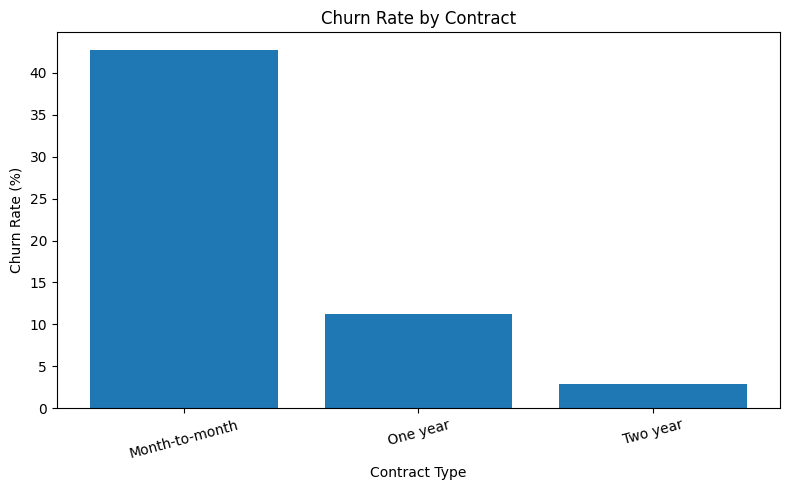

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.bar(contract_churn["Contract"], contract_churn["churn_rate"])
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")
plt.title("Churn Rate by Contract")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

In [ ]:
query = """
SELECT
    CASE
        WHEN tenure <= 12 THEN '0-12 months'
        WHEN tenure <= 24 THEN '13-24 months'
        WHEN tenure <= 48 THEN '25-48 months'
        ELSE '49+ months'
    END AS tenure_group,
    ROUND(
        100.0 * SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) / COUNT(*),
        2
    ) AS churn_rate
FROM customers
GROUP BY tenure_group
ORDER BY
    CASE tenure_group
        WHEN '0-12 months' THEN 1
        WHEN '13-24 months' THEN 2
        WHEN '25-48 months' THEN 3
        WHEN '49+ months' THEN 4
    END;
"""

tenure_churn = pd.read_sql_query(query, conn)
tenure_churn

,tenure_group,churn_rate
0,0-12 months,47.44
1,13-24 months,28.71
2,25-48 months,20.39
3,49+ months,9.51


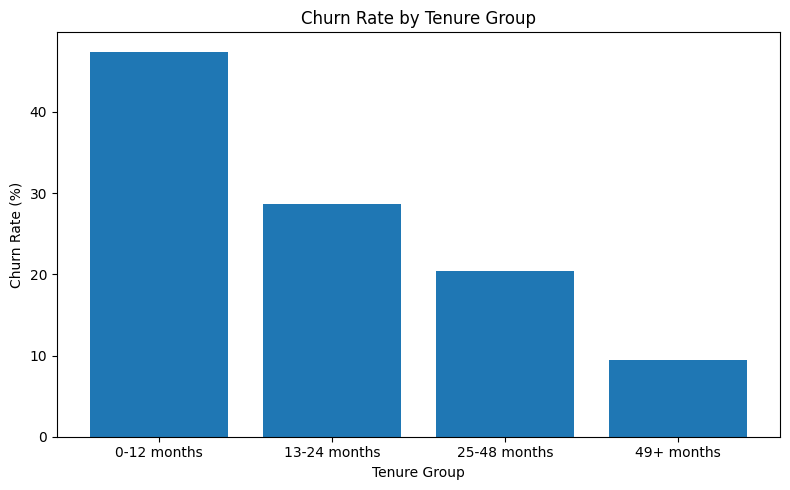

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.bar(tenure_churn["tenure_group"], tenure_churn["churn_rate"])
plt.xlabel("Tenure Group")
plt.ylabel("Churn Rate (%)")
plt.title("Churn Rate by Tenure Group")
plt.tight_layout()
plt.show()

In [ ]:
query = """
SELECT
    InternetService,
    ROUND(
        100.0 * SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) / COUNT(*),
        2
    ) AS churn_rate
FROM customers
GROUP BY InternetService
ORDER BY churn_rate DESC;
"""

internet_churn = pd.read_sql_query(query, conn)
internet_churn

,InternetService,churn_rate
0,Fiber optic,41.89
1,DSL,18.96
2,No,7.40


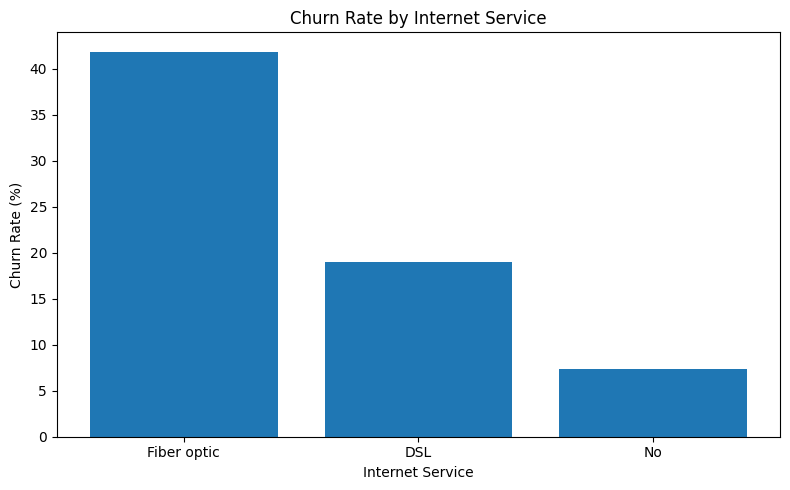

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.bar(internet_churn["InternetService"], internet_churn["churn_rate"])
plt.xlabel("Internet Service")
plt.ylabel("Churn Rate (%)")
plt.title("Churn Rate by Internet Service")
plt.tight_layout()
plt.show()

In [ ]:
query = """
SELECT
    Contract || ' | ' ||
    InternetService || ' | Security: ' ||
    OnlineSecurity || ' | Support: ' ||
    TechSupport AS segment,
    churn_rate
FROM churn_risk_segments
ORDER BY churn_rate DESC
LIMIT 10;
"""

risk_segments = pd.read_sql_query(query, conn)
risk_segments

,segment,churn_rate
0,Month-to-month | Fiber optic | Security: No | ...,60.70
1,Month-to-month | Fiber optic | Security: No | ...,42.40
2,Month-to-month | DSL | Security: No | Support: No,40.56
3,Month-to-month | Fiber optic | Security: Yes |...,39.71
4,Month-to-month | Fiber optic | Security: Yes |...,28.05
5,Month-to-month | DSL | Security: No | Support:...,24.07
6,Month-to-month | DSL | Security: Yes | Support...,23.46
7,One year | Fiber optic | Security: No | Suppor...,20.97
8,One year | Fiber optic | Security: No | Suppor...,20.61
9,Month-to-month | DSL | Security: Yes | Support...,20.33


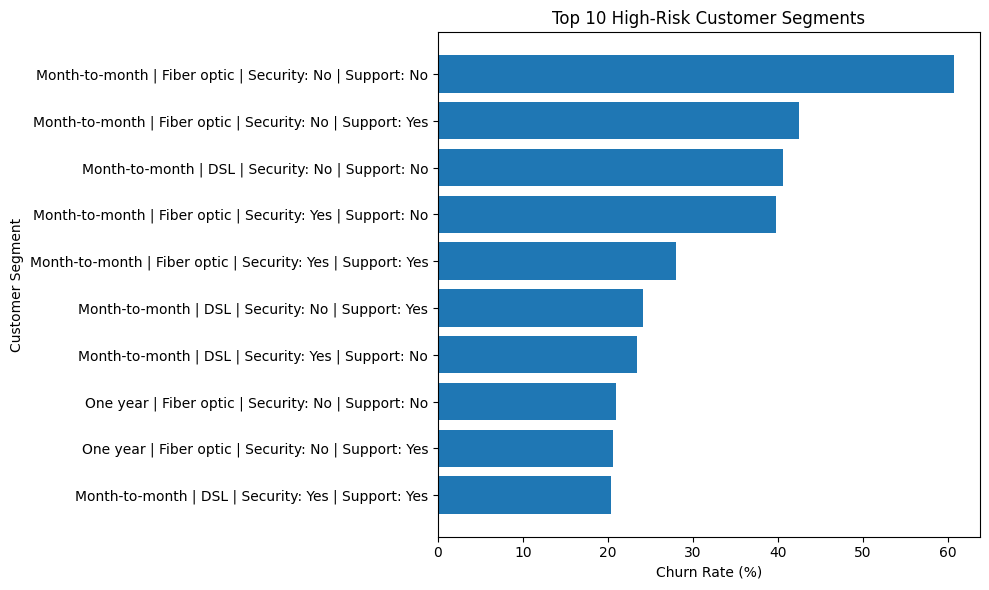

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.barh(risk_segments["segment"], risk_segments["churn_rate"])
plt.xlabel("Churn Rate (%)")
plt.ylabel("Customer Segment")
plt.title("Top 10 High-Risk Customer Segments")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Key Business Findings

- Overall customer churn was **26.54%**, with 1,869 out of 7,043 customers having churned.

- **Month-to-month contracts** had the highest churn rate at **42.71%**, compared with 11.27% for one-year contracts and 2.83% for two-year contracts.

- Customers with **0–12 months of tenure** had the highest churn rate at **47.44%**, while customers with 49+ months of tenure had a much lower churn rate of **9.51%**.

- **Fiber optic customers** had a higher churn rate (**41.89%**) than DSL customers (**18.96%**) and customers without internet service (**7.40%**).

- **Electronic check** users had the highest churn rate among payment methods at **45.29%**, while automatic bank transfer and credit card users had substantially lower churn rates.

- Customers without **Online Security** or **Tech Support** showed substantially higher churn rates than customers who had these services.

- The highest-risk combination identified in the analysis was **month-to-month + fiber optic + no online security + no tech support**, with a churn rate of **60.70%** among 1,524 customers.

> These findings show associations in the dataset and should not be interpreted as proof that any individual factor directly causes churn.

## Conclusion

This analysis used SQL and SQLite to explore customer churn patterns across contract type, tenure, internet service, payment method, and customer support services.

The analysis identified several customer groups with substantially higher churn rates, particularly customers on month-to-month contracts and customers with shorter tenure. The segmentation analysis also highlighted a high-risk group combining month-to-month contracts, fiber optic service, no online security, and no tech support.

These findings can help a business prioritize customer-retention efforts toward segments with higher observed churn.


## SQL Skills Demonstrated

- SELECT, WHERE, ORDER BY
- GROUP BY and aggregate functions
- CASE statements
- HAVING
- CTEs (Common Table Expressions)
- Subqueries
- Window functions and RANK()
- SQL Views
- Multi-dimensional customer segmentation
- Churn-rate calculations
- Data-quality validation

In [ ]:
sql_content = """
-- Customer Churn Analysis
-- SQL Portfolio Project

-- 1. Overall Churn
SELECT
    COUNT(*) AS total_customers,
    SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) AS churned_customers,
    ROUND(
        100.0 * SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) / COUNT(*),
        2
    ) AS churn_rate
FROM customers;


-- 2. Churn by Contract
SELECT
    Contract,
    COUNT(*) AS total_customers,
    SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) AS churned_customers,
    ROUND(
        100.0 * SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) / COUNT(*),
        2
    ) AS churn_rate
FROM customers
GROUP BY Contract
ORDER BY churn_rate DESC;


-- 3. Churn by Internet Service
SELECT
    InternetService,
    COUNT(*) AS total_customers,
    SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) AS churned_customers,
    ROUND(
        100.0 * SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) / COUNT(*),
        2
    ) AS churn_rate
FROM customers
GROUP BY InternetService
ORDER BY churn_rate DESC;


-- 4. Churn by Tenure Group
SELECT
    CASE
        WHEN tenure <= 12 THEN '0-12 months'
        WHEN tenure <= 24 THEN '13-24 months'
        WHEN tenure <= 48 THEN '25-48 months'
        ELSE '49+ months'
    END AS tenure_group,
    COUNT(*) AS total_customers,
    SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) AS churned_customers,
    ROUND(
        100.0 * SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) / COUNT(*),
        2
    ) AS churn_rate
FROM customers
GROUP BY tenure_group
ORDER BY churn_rate DESC;


-- 5. Churn by Payment Method
SELECT
    PaymentMethod,
    COUNT(*) AS total_customers,
    SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) AS churned_customers,
    ROUND(
        100.0 * SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) / COUNT(*),
        2
    ) AS churn_rate
FROM customers
GROUP BY PaymentMethod
ORDER BY churn_rate DESC;


-- 6. Churn by Senior Citizen Status
SELECT
    SeniorCitizen,
    COUNT(*) AS total_customers,
    SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) AS churned_customers,
    ROUND(
        100.0 * SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) / COUNT(*),
        2
    ) AS churn_rate
FROM customers
GROUP BY SeniorCitizen
ORDER BY churn_rate DESC;


-- 7. Churn by Online Security
SELECT
    OnlineSecurity,
    COUNT(*) AS total_customers,
    SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) AS churned_customers,
    ROUND(
        100.0 * SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) / COUNT(*),
        2
    ) AS churn_rate
FROM customers
GROUP BY OnlineSecurity
ORDER BY churn_rate DESC;


-- 8. Churn by Tech Support
SELECT
    TechSupport,
    COUNT(*) AS total_customers,
    SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) AS churned_customers,
    ROUND(
        100.0 * SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) / COUNT(*),
        2
    ) AS churn_rate
FROM customers
GROUP BY TechSupport
ORDER BY churn_rate DESC;


-- 9. Contract + Payment Method
SELECT
    Contract,
    PaymentMethod,
    COUNT(*) AS total_customers,
    SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) AS churned_customers,
    ROUND(
        100.0 * SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) / COUNT(*),
        2
    ) AS churn_rate
FROM customers
GROUP BY Contract, PaymentMethod
ORDER BY churn_rate DESC;


-- 10. High-Risk Customer Segments
SELECT
    Contract,
    InternetService,
    OnlineSecurity,
    TechSupport,
    COUNT(*) AS total_customers,
    SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) AS churned_customers,
    ROUND(
        100.0 * SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) / COUNT(*),
        2
    ) AS churn_rate
FROM customers
GROUP BY
    Contract,
    InternetService,
    OnlineSecurity,
    TechSupport
HAVING COUNT(*) >= 50
ORDER BY churn_rate DESC;


-- 11. CTE Example
WITH churn_summary AS (
    SELECT
        Contract,
        COUNT(*) AS total_customers,
        SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) AS churned_customers
    FROM customers
    GROUP BY Contract
)
SELECT
    Contract,
    total_customers,
    churned_customers,
    ROUND(
        100.0 * churned_customers / total_customers,
        2
    ) AS churn_rate
FROM churn_summary
ORDER BY churn_rate DESC;


-- 12. Subquery Example
SELECT
    Churn,
    COUNT(*) AS total_customers,
    ROUND(AVG(MonthlyCharges), 2) AS avg_monthly_charges
FROM customers
WHERE MonthlyCharges > (
    SELECT AVG(MonthlyCharges)
    FROM customers
)
GROUP BY Churn;


-- 13. Window Function Example
WITH segment_churn AS (
    SELECT
        Contract,
        InternetService,
        COUNT(*) AS total_customers,
        SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) AS churned_customers,
        ROUND(
            100.0 * SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) / COUNT(*),
            2
        ) AS churn_rate
    FROM customers
    GROUP BY Contract, InternetService
)
SELECT
    Contract,
    InternetService,
    total_customers,
    churned_customers,
    churn_rate,
    RANK() OVER (ORDER BY churn_rate DESC) AS churn_rate_rank
FROM segment_churn
ORDER BY churn_rate_rank;


-- 14. Churned vs Retained
SELECT
    Churn,
    COUNT(*) AS total_customers,
    ROUND(AVG(tenure), 2) AS avg_tenure_months,
    ROUND(AVG(MonthlyCharges), 2) AS avg_monthly_charges,
    ROUND(AVG(TotalCharges), 2) AS avg_total_charges
FROM customers
GROUP BY Churn;


-- 15. Top Churned Customers by Monthly Charges
SELECT
    customerID,
    Contract,
    InternetService,
    tenure,
    MonthlyCharges,
    TotalCharges
FROM customers
WHERE Churn = 'Yes'
ORDER BY MonthlyCharges DESC
LIMIT 20;


-- 16. High-Risk Segment View
CREATE VIEW IF NOT EXISTS churn_risk_segments AS
SELECT
    Contract,
    InternetService,
    OnlineSecurity,
    TechSupport,
    COUNT(*) AS total_customers,
    SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) AS churned_customers,
    ROUND(
        100.0 * SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) / COUNT(*),
        2
    ) AS churn_rate
FROM customers
GROUP BY
    Contract,
    InternetService,
    OnlineSecurity,
    TechSupport
HAVING COUNT(*) >= 50;
"""

with open("churn_analysis.sql", "w") as f:
    f.write(sql_content)

print("churn_analysis.sql created successfully.")

churn_analysis.sql created successfully.


In [ ]:
from google.colab import files
files.download("churn_analysis.sql")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>